In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path
import cartopy.crs as ccrs
from shapely.geometry import box, mapping
import pyproj
import time
import geopandas as gpd

from renewable_data_load import *
from climakitae.util.utils import clip_to_shapefile

In [3]:
from sei_computation import compute_sei, compute_standardized_index, stack_doy_year_to_time

# 1. Load generation data and divide into regional averages

In [7]:
# Analysis parameters
domain = "d02"
variable = "cf"
reference_gwl = 0.8
target_gwls = [0.8, 2.0]

simulations = ["mpi-esm1-2-hr", "miroc6", "taiesm1", "ec-earth3"]

# Data directory
data_dir = Path("../../data/")

In [4]:
resource = 'windpower'
module = 'onshore'

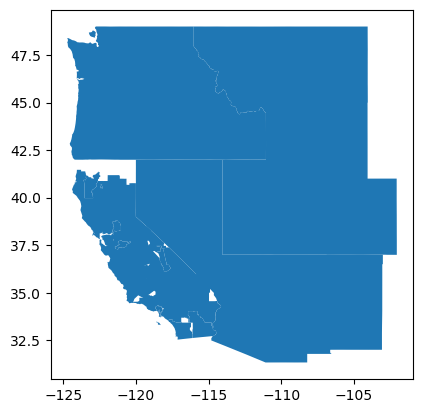

In [5]:
# load shapefile to examine
shapefile_path = Path("../../data/load_zone_shapefiles/allLoadZones.shp")

gdf = gpd.read_file(shapefile_path)
gdf.plot()

# need to manually set the CRS for the drought mask
wrf_crs = pyproj.CRS(
        """+proj=lcc +lat_0=38. +lon_0=-70. +lat_1=30.
        +lat_2=60. +R=6370000. +units=m +no_defs"""
    )

# and set the shapefile to the same CRS
gdf_reprojected = gdf.to_crs(wrf_crs.to_string())

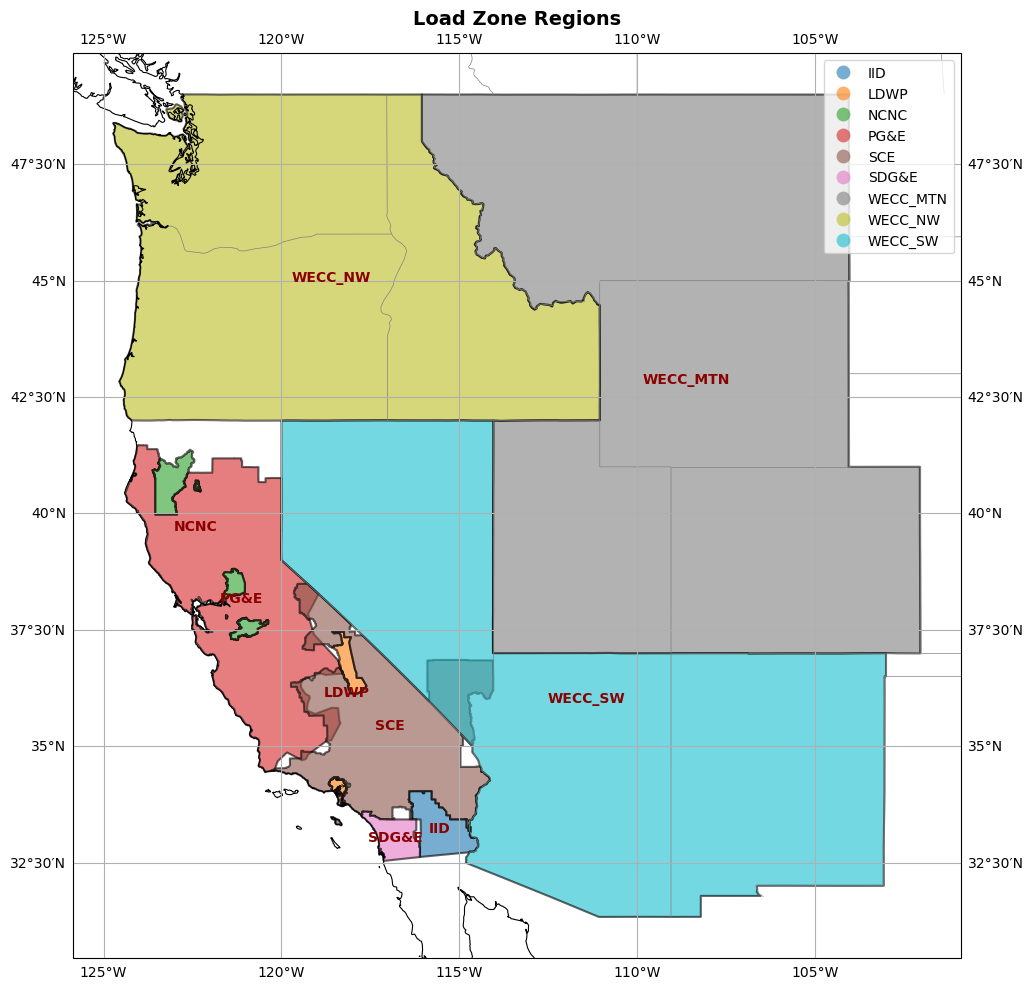

In [6]:
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Transform the reprojected data back to lat/lon for PlateCarree
gdf_latlon = gdf_reprojected.to_crs(epsg=4326)

# Plot with different colors for each region
gdf_latlon.plot(ax=ax, edgecolor='black', column='name', 
                cmap='tab10', linewidth=1.5, alpha=0.6, 
                legend=True, transform=ccrs.PlateCarree())

# Add region names as labels
for idx, row in gdf_latlon.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['name'], 
            fontsize=10, ha='center', va='center', 
            weight='bold', color='darkred',
            transform=ccrs.PlateCarree())

# Add US state borders
states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none'
)
ax.add_feature(states, edgecolor='gray', linewidth=0.5)

ax.coastlines(resolution='10m', linewidth=0.8)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Load Zone Regions', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


In [7]:
    variable = "cf"
    frequency = "day"
    domain = 'd02'


In [8]:

for simulation in simulations:
    ren_ds = get_ren_data_concat(resource, module, domain, variable, frequency, simulation)

    regional_gens = []

    for index, row in gdf_reprojected.iterrows():
        region_name = row['name']
        geom = [mapping(row.geometry)]

        regional_gen = ren_ds.rio.clip(
        geom,
        crs=wrf_crs,
        drop=True,
        all_touched=True,
        )

        # aggregate with MEAN
        regional_gen = regional_gen.mean(['x','y'])

        regional_gen['region'] = region_name
        regional_gen['resource'] = resource
        regional_gen['module'] = module

        regional_gens.append(regional_gen)
    region_gen_ds = xr.concat(regional_gens, dim='region', join='outer')


    region_gen_ds = region_gen_ds.compute()


    # get reference period of GWL 0.8 

    # Get bounds for reference GWL period
    WRF_sim_name = sim_name_dict[simulation]
    model = WRF_sim_name.split("_")[1]
    ensemble_member = WRF_sim_name.split("_")[2]
    ref_start_year, ref_end_year = get_gwl_crossing_period(model, ensemble_member, reference_gwl)

    region_gen_ds_ref = region_gen_ds.sel(time=slice(f"{ref_start_year}-01-01",f"{ref_end_year}-12-31"))

    sei = compute_sei(region_gen_ds_ref, region_gen_ds, window_size=60, fill_missing_year=True)

    save_plots = True

    if save_plots:
        # Create output directory if it doesn't exist
        output_dir = Path(f"figures/{resource}_{module}")
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Plot for each region
        for region_name in sei.region.values:
            fig, ax = plt.subplots(figsize=(12, 4))
            xr.plot.imshow(
                sei.sel(region=region_name).T,
                ax=ax,
                levels=[-1.96, -1.64, -1.28, 0, 1.28, 1.64, 1.96],
                cmap="PuOr_r",
                cbar_kwargs={'pad': 0.02}
            )
            plt.title(f"{region_name} {simulation} Daily Generation {resource} SEI")
            plt.ylabel("Year")
            plt.xlabel("Day of Year")
            plt.tight_layout()
            
            # Save figure
            fig_filename = f"{region_name}_{simulation}_{resource}_{module}_SEI.png"
            plt.savefig(output_dir / fig_filename, dpi=300, bbox_inches='tight')
            plt.close()
            
        print(f"Saved SEI plots for all regions to {output_dir}")
    else:
        # Original single region plot
        region = 'PG&E'
        fig, ax = plt.subplots(figsize=(12, 4))
        xr.plot.imshow(
            sei.sel(region=region).T,
            ax=ax,
            levels=[-1.96, -1.64, -1.28, 0, 1.28, 1.64, 1.96],
            cmap="PuOr_r",
            cbar_kwargs={'pad': 0.02}
        )
        plt.title(f"{region} {simulation} Daily Generation {resource} SEI")
        plt.ylabel("Year")
        plt.xlabel("Day of Year")
        plt.tight_layout()
        plt.show()


    sei = stack_doy_year_to_time(sei)

    # save SEI to netCDF in the 
    output_path = f"{data_dir}/SEI/{resource}_{module}_{domain}_{variable}_{simulation}_gwlref{reference_gwl}_regional_SEI.nc"
    sei.to_netcdf(output_path)

    # Create binary drought mask for entire time series
    # 1 where drought_ds < 0 (below threshold), 0 otherwise
    drought_mask = xr.where(sei < -1.28, 1, 0)
    drought_mask.name = "drought_mask"

    # save into the drought mask folder
    drought_mask = drought_mask.load()

    # Save drought mask to file
    mask_output_file = f"{data_dir}/drought_masks/{resource}_{module}_{domain}_{variable}_{simulation}_ts_regional_drought_mask.zarr"

    # Add metadata to drought mask
    drought_mask.attrs['resource'] = resource
    drought_mask.attrs['module'] = module
    drought_mask.attrs['domain'] = domain
    drought_mask.attrs['variable'] = variable
    drought_mask.attrs['simulation'] = simulation
    drought_mask.attrs['reference_gwl'] = float(reference_gwl)
    drought_mask.attrs['description'] = 'Binary drought mask: 1 = drought (below threshold), 0 = no drought'

    # Clear encoding from data variable and all coordinates to avoid codec conflicts
    drought_mask.encoding = {}
    for coord in drought_mask.coords:
        drought_mask.coords[coord].encoding = {}

    # Save with Zarr v3 - let xarray choose v3-compatible codecs
    # Only specify dtype, let compression use v3 defaults
    encoding = {'drought_mask': {'dtype': 'int32'}}
    drought_mask.to_zarr(mask_output_file, encoding=encoding, mode='w', consolidated=True)

Saved SEI plots for all regions to figures/windpower_onshore
Saved SEI plots for all regions to figures/windpower_onshore
Saved SEI plots for all regions to figures/windpower_onshore
Saved SEI plots for all regions to figures/windpower_onshore


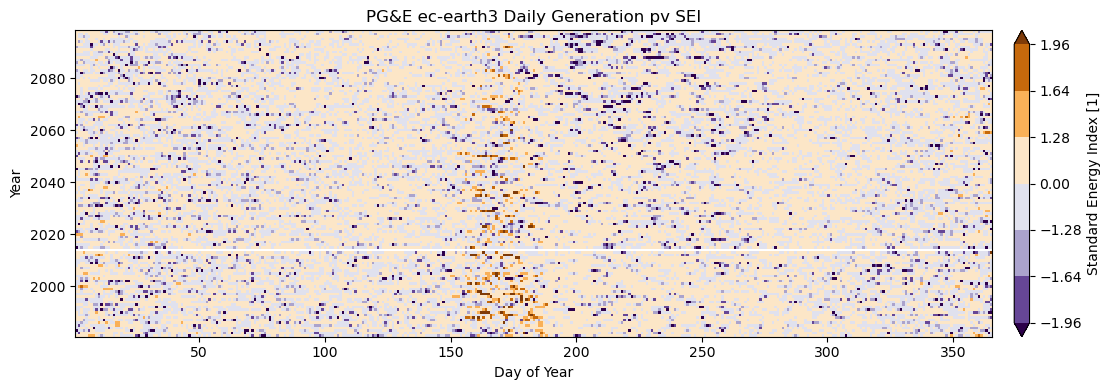

# Offshore wind - Regional SEI approach

In [9]:
resource = 'windpower'
module = 'offshore'
domain = 'd03'  # Offshore uses d03
variable = "cf"
frequency = "day"
reference_gwl = 0.8

# Data directory
data_dir = Path("../../data/")

In [10]:
# Define offshore region boundaries
# north_region is above 37.0 and west of -123
# south_region is below 37.0 and west of -117.2

offshore_regions = {
    'north_offshore': {'lat_min': 37, 'lat_max': None, 'lon_min': None, 'lon_max': -123},
    'south_offshore': {'lat_min': None, 'lat_max': 37, 'lon_min': None, 'lon_max': -117.2}
}

In [11]:
for simulation in simulations:
    ren_ds = get_ren_data_concat(resource, module, domain, variable, frequency, simulation)
    
    regional_gens = []
    
    for region_name, bounds in offshore_regions.items():
        # Filter by latitude bounds
        region_data = ren_ds
        if bounds['lat_min'] is not None:
            region_data = region_data.where(region_data['lat'] >= bounds['lat_min'])
        if bounds['lat_max'] is not None:
            region_data = region_data.where(region_data['lat'] < bounds['lat_max'])
        
        # Filter by longitude bounds
        if bounds['lon_min'] is not None:
            region_data = region_data.where(region_data['lon'] >= bounds['lon_min'])
        if bounds['lon_max'] is not None:
            region_data = region_data.where(region_data['lon'] <= bounds['lon_max'])
        
        # Aggregate with MEAN across spatial dimensions
        regional_gen = region_data.mean(['x', 'y'])
        
        regional_gen['region'] = region_name
        regional_gen['resource'] = resource
        regional_gen['module'] = module
        
        regional_gens.append(regional_gen)
    
    region_gen_ds = xr.concat(regional_gens, dim='region', join='outer')
    region_gen_ds = region_gen_ds.compute()
    
    # Get reference period of GWL 0.8
    WRF_sim_name = sim_name_dict[simulation]
    model = WRF_sim_name.split("_")[1]
    ensemble_member = WRF_sim_name.split("_")[2]
    ref_start_year, ref_end_year = get_gwl_crossing_period(model, ensemble_member, reference_gwl)
    
    region_gen_ds_ref = region_gen_ds.sel(time=slice(f"{ref_start_year}-01-01", f"{ref_end_year}-12-31"))
    
    # Compute SEI
    sei = compute_sei(region_gen_ds_ref, region_gen_ds, window_size=60, fill_missing_year=True)
    
    save_plots = True
    
    if save_plots:
        # Create output directory if it doesn't exist
        output_dir = Path(f"figures/{resource}_{module}")
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Plot for each offshore region
        for region_name in sei.region.values:
            fig, ax = plt.subplots(figsize=(12, 4))
            xr.plot.imshow(
                sei.sel(region=region_name).T,
                ax=ax,
                levels=[-1.96, -1.64, -1.28, 0, 1.28, 1.64, 1.96],
                cmap="PuOr_r",
                cbar_kwargs={'pad': 0.02}
            )
            plt.title(f"{region_name} {simulation} Daily Generation {resource} SEI")
            plt.ylabel("Year")
            plt.xlabel("Day of Year")
            plt.tight_layout()
            
            # Save figure
            fig_filename = f"{region_name}_{simulation}_{resource}_{module}_SEI.png"
            plt.savefig(output_dir / fig_filename, dpi=300, bbox_inches='tight')
            plt.close()
            
        print(f"Saved SEI plots for offshore regions to {output_dir}")
    
    # Stack back to time dimension
    sei = stack_doy_year_to_time(sei)
    
    # Save SEI to netCDF
    output_path = f"{data_dir}/SEI/{resource}_{module}_{domain}_{variable}_{simulation}_gwlref{reference_gwl}_regional_SEI.nc"
    sei.to_netcdf(output_path)
    
    # Create binary drought mask for entire time series
    # 1 where sei < -1.28 (below threshold), 0 otherwise
    drought_mask = xr.where(sei < -1.28, 1, 0)
    drought_mask.name = "drought_mask"
    
    # Load into memory
    drought_mask = drought_mask.load()
    
    # Save drought mask to file
    mask_output_file = f"{data_dir}/drought_masks/{resource}_{module}_{domain}_{variable}_{simulation}_ts_regional_drought_mask.zarr"
    
    # Add metadata to drought mask
    drought_mask.attrs['resource'] = resource
    drought_mask.attrs['module'] = module
    drought_mask.attrs['domain'] = domain
    drought_mask.attrs['variable'] = variable
    drought_mask.attrs['simulation'] = simulation
    drought_mask.attrs['reference_gwl'] = float(reference_gwl)
    drought_mask.attrs['description'] = 'Binary drought mask: 1 = drought (below threshold), 0 = no drought'
    
    # Clear encoding from data variable and all coordinates to avoid codec conflicts
    drought_mask.encoding = {}
    for coord in drought_mask.coords:
        drought_mask.coords[coord].encoding = {}
    
    # Save with Zarr v3 - let xarray choose v3-compatible codecs
    encoding = {'drought_mask': {'dtype': 'int32'}}
    drought_mask.to_zarr(mask_output_file, encoding=encoding, mode='w', consolidated=True)

Saved SEI plots for offshore regions to figures/windpower_offshore
Saved SEI plots for offshore regions to figures/windpower_offshore
Saved SEI plots for offshore regions to figures/windpower_offshore
Saved SEI plots for offshore regions to figures/windpower_offshore
